In [3]:
from scipy.stats import poisson, binom, expon
import matplotlib.pyplot as plt
import math
import numpy as np

In [4]:
# flusso CR al livello del mare, con momento > 10 GeV/c
I_0 = 0.001 # cm^-2 s^-1 sr^-1

# angolo solido full-sky
omega  = 2 * math.pi   # sr

# superficie rivelatore
area   = 100           # cm^2

# tempo di presa dati
hours  = 1             # hr
t_data = hours * 3600  # s

muon_rate = I_0 * omega * t_data * area # N di muoni totali (rate integrato)
print("Il rate integrato è: ", muon_rate)

e1 = expon(scale=50, loc=10)

energies = e1.rvs(size = int(muon_rate))
print(energies)
len(energies)

# help(expon)

Il rate integrato è:  2261.946710584651
[138.26544171  11.12564631  85.70586189 ...  14.91245175  12.37499929
  65.38864641]


2261

Text(0, 0.5, 'CR - Integrated Flux')

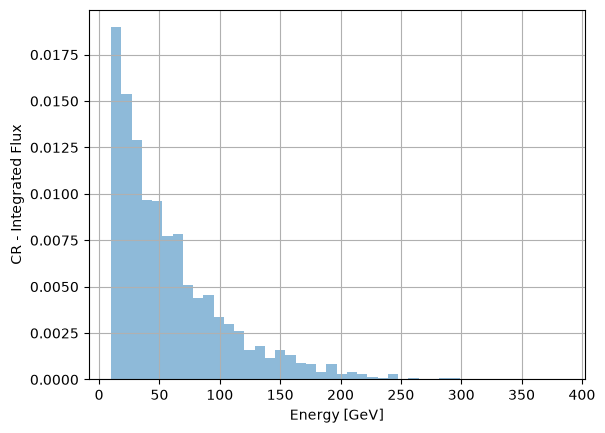

In [5]:
fig, ax = plt.subplots()
ax.hist(energies, density=True, bins="auto", histtype="stepfilled", alpha=0.5)
ax.grid(True)
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel("CR - Integrated Flux")

In [6]:
muon_prob = poisson(muon_rate) # muon_rate è il valore atteso della distribuzione poissoniana appena creata
ndatasets = 10000

x = np.arange(muon_prob.ppf(10/ndatasets), muon_prob.ppf(1.0 - 1.0/ndatasets)) # PPF = percent point function (funzione quantile): INVERSA della CDF
y = muon_prob.pmf(x)

Text(0.5, 1.0, 'Percent Point Function')

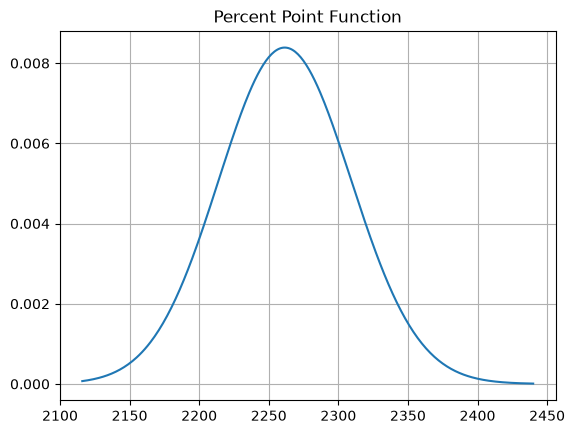

In [7]:
fig2, axs = plt.subplots()
axs.plot(x, y)
axs.grid(True)
axs.set_title("Percent Point Function")

Text(0.5, 1.0, 'Cumulative Density Function')

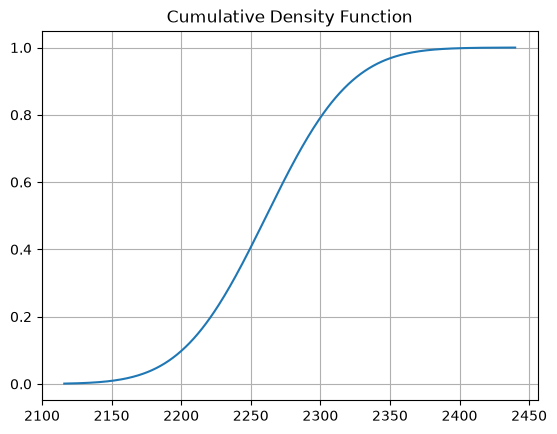

In [12]:
y = poisson.cdf(x, muon_rate, 0)
fig3, ax3 = plt.subplots()
ax3.plot(x, y)
ax3.grid(True)
ax3.set_title("Cumulative Density Function")